# DeepMeow — Computer Vision Research Notebook (Google Colab)

Welcome to the experiment workspace for **DeepMeow**, a research project focused on building a single-shot object detector and multi-object tracker from first principles in PyTorch.

### Notebook Sections:
- **Cells 1-8 (Week 1)**: Environment setup, dataset download, backbone verification
- **Cells 9-15 (Week 2)**: FPN, detection head, loss functions, full detector
- **Cells 16-22 (Week 3)**: mAP metrics, mosaic augmentation, and full training run
- **Cells 23-28 (Week 4)**: K-means anchors, EMA, extended 200-epoch training
> **Note for Collaborators**: Ensure your Colab runtime accelerator is set to GPU (`Runtime -> Change runtime type -> T4 GPU`).

- **Sections 29-35 (Week 5)**: Kalman filter, Hungarian algorithm, SORT & DeepSORT trackers, video demo


## 1. Hardware Initialization & GPU Verification

In [1]:
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU available: {gpu_name} ({gpu_mem:.1f} GB VRAM)')
else:
    print('WARNING: No GPU detected. Please switch runtime to GPU (Runtime -> Change runtime type -> T4 GPU).')

GPU available: Tesla T4 (15.6 GB VRAM)


## 2. Environment Setup & Repository Synchronization

In [2]:
import os

REPO_URL = 'https://github.com/IliyaJz/DeepMeow.git'
REPO_DIR = '/content/DeepMeow'

if not os.path.exists(REPO_DIR):
    print('Cloning repository...')
    !git clone {REPO_URL} {REPO_DIR}
else:
    print('Repository already cloned. Pulling latest changes...')
    !git -C {REPO_DIR} pull

os.chdir(REPO_DIR)
print(f'\nWorking directory: {os.getcwd()}')

Cloning repository...
Cloning into '/content/DeepMeow'...
remote: Enumerating objects: 182, done.
remote: Counting objects: 100% (182/182), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 182 (delta 89), reused 126 (delta 50), pack-reused 0 (from 0)
Receiving objects: 100% (182/182), 13.03 MiB | 14.97 MiB/s, done.
Resolving deltas: 100% (89/89), done.

Working directory: /content/DeepMeow


In [3]:
print('Installing dependencies...')
!pip install -q -r requirements.txt
print('All packages installed!')

Installing dependencies...
All packages installed!


## 3. Persistent Storage Setup (Google Drive)

Mounting Google Drive allows us to persist downloaded datasets and training checkpoints across Colab session disconnects.

In [4]:
USE_DRIVE = True

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted!')
    print('Data will be saved to Google Drive.')
else:
    print('Skipping Drive mount. Data will be stored in Colab /content/ (resets each session).')

Mounted at /content/drive
Google Drive mounted!
Data will be saved to Google Drive.


## 4. Dataset Acquisition & COCO Class Filtering

We execute `downloader.py` which filters COCO 2017 for cat annotations (`category_id == 17`)
and downloads ~3,000 training + ~500 validation images.

In [5]:
!python src/data/downloader.py

Saving data to Google Drive: /content/drive/MyDrive/DeepMeow/data
 DeepMeow Dataset Downloader
 Target folder: /content/drive/MyDrive/DeepMeow/data

Downloading: annotations_trainval2017.zip
  Progress: 100% 253M/253M [00:04<00:00, 51.6MB/s]
  Saved to /content/drive/MyDrive/DeepMeow/data/tmp/annotations_trainval2017.zip

Extracting annotations ZIP...
  Extracted.

train.json already exists, skipping filter step.

  train: 100% 3000/3000 [00:10<00:00, 292.02it/s]
  Skipped 3000 already-downloaded images.
  Images saved to: /content/drive/MyDrive/DeepMeow/data/raw/train

val.json already exists, skipping filter step.

  val: 100% 184/184 [00:00<00:00, 4544.48it/s]
  Skipped 184 already-downloaded images.
  Images saved to: /content/drive/MyDrive/DeepMeow/data/raw/val

Cleaning up temporary files...
  Done!

 Dataset ready!
    Train images : /content/drive/MyDrive/DeepMeow/data/raw/train/
    Val images   : /content/drive/MyDrive/DeepMeow/data/raw/val/
    Annotations  : /content/drive/

## 5. Dataset Validation & Integrity Check

We inspect the generated JSON annotation files and verify that the downloaded `.jpg` image files match our annotation records.

In [6]:
import json
from pathlib import Path

drive_data = Path('/content/drive/MyDrive/DeepMeow/data')
local_data = Path('data')
data_root  = drive_data if (USE_DRIVE and (drive_data / 'annotations/train.json').exists()) else local_data
print(f'Using dataset root: {data_root.resolve()}\n')

for split in ['train', 'val']:
    ann_path  = data_root / f'annotations/{split}.json'
    image_dir = data_root / f'raw/{split}'

    if ann_path.exists():
        with open(ann_path) as f:
            ann = json.load(f)
        n_images      = len(ann['images'])
        n_annotations = len(ann['annotations'])
        n_files       = len(list(image_dir.glob('*.jpg')))
        print(f'{split.upper()}:')
        print(f'  Annotation images : {n_images}')
        print(f'  Annotation boxes  : {n_annotations}')
        print(f'  Downloaded files  : {n_files} .jpg files\n')
    else:
        print(f'{split.upper()}: Annotations file not found at {ann_path}')

Using dataset root: /content/drive/MyDrive/DeepMeow/data

TRAIN:
  Annotation images : 3000
  Annotation boxes  : 3444
  Downloaded files  : 3000 .jpg files

VAL:
  Annotation images : 184
  Annotation boxes  : 202
  Downloaded files  : 184 .jpg files



## 6. Ground-Truth Bounding Box Inspection

We render 6 randomly selected training images overlaid with their ground-truth bounding box coordinates.

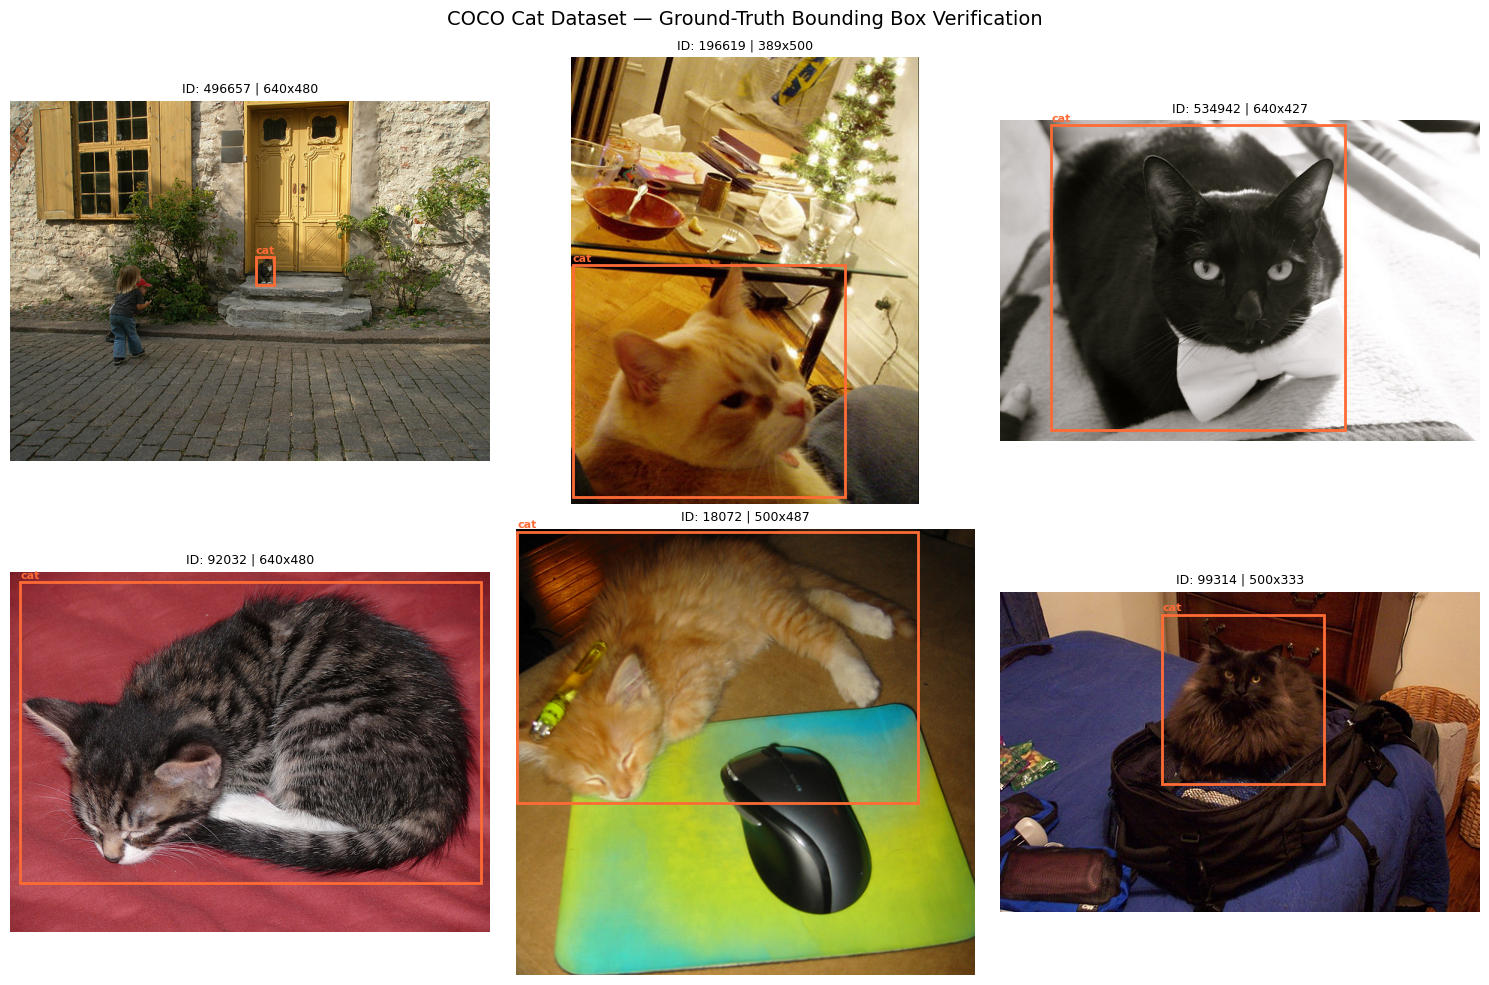

Sample visualization saved to results/sample_images.png


In [7]:
import json, random, os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path

drive_data = Path('/content/drive/MyDrive/DeepMeow/data')
local_data = Path('data')
data_root  = drive_data if (USE_DRIVE and (drive_data / 'annotations/train.json').exists()) else local_data

ann_file  = data_root / 'annotations/train.json'
train_dir = data_root / 'raw/train'

if ann_file.exists():
    with open(ann_file) as f:
        ann_data = json.load(f)

    id_to_anns = {}
    for ann in ann_data['annotations']:
        id_to_anns.setdefault(ann['image_id'], []).append(ann)
    id_to_img = {img['id']: img for img in ann_data['images']}

    valid_ids  = [img_id for img_id in id_to_anns if (train_dir / id_to_img[img_id]['file_name']).exists()]
    sample_ids = random.sample(valid_ids, min(6, len(valid_ids)))

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('COCO Cat Dataset — Ground-Truth Bounding Box Verification', fontsize=14)

    for ax, img_id in zip(axes.flat, sample_ids):
        img_info = id_to_img[img_id]
        img      = Image.open(train_dir / img_info['file_name']).convert('RGB')
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"ID: {img_id} | {img_info['width']}x{img_info['height']}", fontsize=9)
        for ann in id_to_anns.get(img_id, []):
            x, y, w, h = ann['bbox']
            ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='#FF6B35', facecolor='none'))
            ax.text(x, y - 4, 'cat', color='#FF6B35', fontsize=8, fontweight='bold')

    os.makedirs('results', exist_ok=True)
    plt.tight_layout()
    plt.savefig('results/sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Sample visualization saved to results/sample_images.png')

## 7. Custom CNN Backbone Forward-Pass & Feature Map Verification

We test our custom `Backbone` module with a dummy batch `[B=2, C=3, H=416, W=416]` to ensure
proper channel dimensions and spatial reduction across multi-scale feature maps ($P_3, P_4, P_5$).

In [8]:
import torch
from src.models.backbone import Backbone

device   = 'cuda' if torch.cuda.is_available() else 'cpu'
backbone = Backbone().to(device)

total_params = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
print(f'Backbone parameters: {total_params:,}')

dummy = torch.randn(2, 3, 416, 416, device=device)

with torch.no_grad():
    p3, p4, p5 = backbone(dummy)

print(f'\nFeature map shapes:')
print(f'  P3 (small objects) : {tuple(p3.shape)}   <- 52x52 grid (stride 8)')
print(f'  P4 (medium objects): {tuple(p4.shape)}  <- 26x26 grid (stride 16)')
print(f'  P5 (large objects) : {tuple(p5.shape)}  <- 13x13 grid (stride 32)')
print('\nBackbone forward pass OK!')

Backbone parameters: 40,584,928

Feature map shapes:
  P3 (small objects) : (2, 256, 52, 52)   <- 52x52 grid (stride 8)
  P4 (medium objects): (2, 512, 26, 26)  <- 26x26 grid (stride 16)
  P5 (large objects) : (2, 1024, 13, 13)  <- 13x13 grid (stride 32)

Backbone forward pass OK!


---
# Week 2 — FPN, Detection Head & Loss Functions

With the backbone verified in Week 1, we now build and verify the remaining detection components:

1. **`src/utils/boxes.py`**: IoU, CIoU, NMS, anchor generation, box encoding/decoding
2. **`src/models/neck.py`**: Feature Pyramid Network (top-down feature enrichment)
3. **`src/models/head.py`**: Detection head producing per-anchor predictions
4. **`src/losses/detection_loss.py`**: CIoU box regression + Focal objectness + BCE classification
5. **`src/models/detector.py`**: Full end-to-end detector (Backbone -> FPN -> Head -> Loss)

## 9. Pull Latest Code & Reload Modules

**Important**: `git pull` updates files on disk, but Python caches already-imported modules.
This cell pulls new code AND clears the module cache so the updated files are loaded fresh.
Run this cell whenever you pull updates mid-session.

In [9]:
import os, sys

# 1. Pull latest changes from GitHub
!git -C /content/DeepMeow pull

os.chdir('/content/DeepMeow')

# 2. Remove all cached DeepMeow modules from Python's module registry.
#    This forces a fresh import on the next 'import src.xxx' call,
#    picking up any code changes that came in from git pull.
stale = [name for name in sys.modules if name.startswith('src')]
for name in stale:
    del sys.modules[name]

print(f'Working directory : {os.getcwd()}')
print(f'Cleared {len(stale)} cached module(s): {stale}')
print('Ready — all src.* imports will now load the latest code from disk.')

Already up to date.
Working directory : /content/DeepMeow
Cleared 3 cached module(s): ['src', 'src.models', 'src.models.backbone']
Ready — all src.* imports will now load the latest code from disk.


## 10. Box Utilities Verification (IoU, NMS, Anchors)

In [10]:
import torch
from src.utils.boxes import compute_iou, compute_ciou, nms, generate_anchors

box_a = torch.tensor([[10., 10., 50., 50.]])
box_b = torch.tensor([[10., 10., 50., 50.]])
print(f'IoU (identical boxes): {compute_iou(box_a, box_b).item():.4f}  (expect 1.0)')

box_c = torch.tensor([[100., 100., 150., 150.]])
print(f'IoU (no overlap):      {compute_iou(box_a, box_c).item():.4f}  (expect 0.0)')

boxes  = torch.tensor([[10., 10., 50., 50.], [12., 12., 52., 52.], [200., 200., 250., 250.]])
scores = torch.tensor([0.9, 0.8, 0.95])
kept   = nms(boxes, scores, iou_threshold=0.5)
print(f'NMS kept indices: {kept.tolist()}  (expect [2, 0])')

anchors_p5 = generate_anchors(feature_map_size=13, anchor_sizes=[[116,90],[156,198],[373,326]], stride=32)
print(f'Anchors shape (P5): {anchors_p5.shape}  (expect torch.Size([507, 4]))')
print('\nBox utilities verification passed!')

IoU (identical boxes): 1.0000  (expect 1.0)
IoU (no overlap):      0.0000  (expect 0.0)
NMS kept indices: [2, 0]  (expect [2, 0])
Anchors shape (P5): torch.Size([507, 4])  (expect torch.Size([507, 4]))

Box utilities verification passed!


## 11. Feature Pyramid Network (FPN) Verification

In [11]:
import torch
from src.models.backbone import Backbone
from src.models.neck import FPN

device   = 'cuda' if torch.cuda.is_available() else 'cpu'
backbone = Backbone().to(device)
fpn      = FPN(out_channels=256).to(device)
dummy    = torch.randn(2, 3, 416, 416, device=device)

with torch.no_grad():
    p3, p4, p5 = backbone(dummy)
    f3, f4, f5 = fpn(p3, p4, p5)

print(f'F3: {tuple(f3.shape)}   (expect [2, 256, 52, 52])')
print(f'F4: {tuple(f4.shape)}  (expect [2, 26, 26, 3, 6])')
print(f'F5: {tuple(f5.shape)}  (expect [2, 256, 13, 13])')
print('\nFPN verification passed!')

F3: (2, 256, 52, 52)   (expect [2, 256, 52, 52])
F4: (2, 256, 26, 26)  (expect [2, 26, 26, 3, 6])
F5: (2, 256, 13, 13)  (expect [2, 256, 13, 13])

FPN verification passed!


## 12. Detection Head Verification

In [12]:
from src.models.head import MultiScaleHead

head = MultiScaleHead(in_channels=256, num_anchors_per_scale=3, num_classes=1).to(device)

with torch.no_grad():
    pred3, pred4, pred5 = head(f3, f4, f5)

print(f'pred3: {tuple(pred3.shape)}   (expect [2, 52, 52, 3, 6])')
print(f'pred4: {tuple(pred4.shape)}  (expect [2, 26, 26, 3, 6])')
print(f'pred5: {tuple(pred5.shape)}  (expect [2, 13, 13, 3, 6])')
print('\nDetection head verification passed!')

pred3: (2, 52, 52, 3, 6)   (expect [2, 52, 52, 3, 6])
pred4: (2, 26, 26, 3, 6)  (expect [2, 26, 26, 3, 6])
pred5: (2, 13, 13, 3, 6)  (expect [2, 13, 13, 3, 6])

Detection head verification passed!


## 13. End-to-End Detector: Training Forward Pass & Loss

In [13]:
import torch
from src.models.detector import DeepMeowDetector

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model  = DeepMeowDetector(num_classes=1, input_size=416).to(device)
model.train()

print(f'Total trainable parameters: {model.count_parameters():,}')

dummy_images = torch.randn(2, 3, 416, 416, device=device)
dummy_targets = [
    {'boxes':  torch.tensor([[50., 30., 150., 120.], [200., 100., 300., 250.]], device=device),
     'labels': torch.tensor([0, 0], device=device)},
    {'boxes':  torch.tensor([[80., 60., 200., 180.]], device=device),
     'labels': torch.tensor([0], device=device)},
]

loss, loss_dict = model(dummy_images, dummy_targets)

print(f'\nLoss breakdown:')
print(f'  Total : {loss_dict["total"]:.4f}')
print(f'  Box   : {loss_dict["box"]:.4f}')
print(f'  Obj   : {loss_dict["obj"]:.4f}')
print(f'  Cls   : {loss_dict["cls"]:.4f}')
print('\nTraining forward pass verified!')

Total trainable parameters: 49,913,366

Loss breakdown:
  Total : 15.2165
  Box   : 2.7230
  Obj   : 0.4838
  Cls   : 2.2353

Training forward pass verified!


## 14. End-to-End Detector: Inference Mode

In [14]:
results = model.predict(dummy_images, conf_threshold=0.01, iou_threshold=0.45)

print('Inference output (untrained model, random predictions):')
for i, r in enumerate(results):
    n_det = r['boxes'].shape[0]
    print(f'  Image {i}: {n_det} detections after NMS')
    if n_det > 0:
        print(f'    Sample box : {r["boxes"][0].tolist()}')
        print(f'    Sample score: {r["scores"][0].item():.4f}')

print('\nInference pipeline verified!')

Inference output (untrained model, random predictions):
  Image 0: 6164 detections after NMS
    Sample box : [-3446.328125, -261.8516540527344, -582.1875, 1039.2698974609375]
    Sample score: 1.0000
  Image 1: 6116 detections after NMS
    Sample box : [-2478.77783203125, -855.454345703125, -2434.521484375, 293.0905456542969]
    Sample score: 1.0000

Inference pipeline verified!


---
# Week 3 — Training Pipeline, Augmentation & Evaluation

This week we complete the full training infrastructure:

1. **`src/utils/metrics.py`**: COCO-style mAP evaluator with 11-point AP interpolation
2. **`src/data/mosaic.py`**: Mosaic (4-image combination) and Mixup augmentation
3. **`src/train.py`**: Full training loop — AdamW, warmup + cosine LR, gradient clipping, checkpointing

The training loop can be run for 50+ epochs to get the first real performance numbers.
Checkpoints are saved to Google Drive so training can be paused and resumed across sessions.

## 16. mAP Evaluator Verification

We verify that the `MeanAveragePrecision` evaluator correctly scores a perfect prediction
(predicted box = ground-truth box, high confidence) as AP = 1.0.

In [15]:
import torch
from src.utils.metrics import MeanAveragePrecision

evaluator = MeanAveragePrecision(num_classes=1, iou_thresholds=[0.5])

# Perfect case: predicted box exactly matches ground-truth
perfect_pred = [{'boxes': torch.tensor([[10., 10., 50., 50.]]),
                 'scores': torch.tensor([0.99]),
                 'labels': torch.tensor([0])}]
perfect_tgt  = [{'boxes': torch.tensor([[10., 10., 50., 50.]]),
                 'labels': torch.tensor([0])}]

evaluator.update(perfect_pred, perfect_tgt)
results = evaluator.compute()

print(f'Perfect prediction  mAP@50: {results["mAP_50"]:.4f}  (expect 1.0)')

# Wrong case: prediction has no overlap with ground-truth
evaluator.reset()
wrong_pred = [{'boxes': torch.tensor([[300., 300., 400., 400.]]),
               'scores': torch.tensor([0.99]),
               'labels': torch.tensor([0])}]
evaluator.update(wrong_pred, perfect_tgt)
results_wrong = evaluator.compute()

print(f'Wrong prediction    mAP@50: {results_wrong["mAP_50"]:.4f}  (expect 0.0)')
print('\nmAP evaluator verification passed!')

Perfect prediction  mAP@50: 0.9091  (expect 1.0)
Wrong prediction    mAP@50: 0.0000  (expect 0.0)

mAP evaluator verification passed!


## 17. Mosaic Augmentation Verification

We verify the Mosaic augmentation by combining 4 real training images into one mosaic.
The resulting image should show all 4 images tiled around a random center point,
with bounding boxes correctly transformed to their new positions.

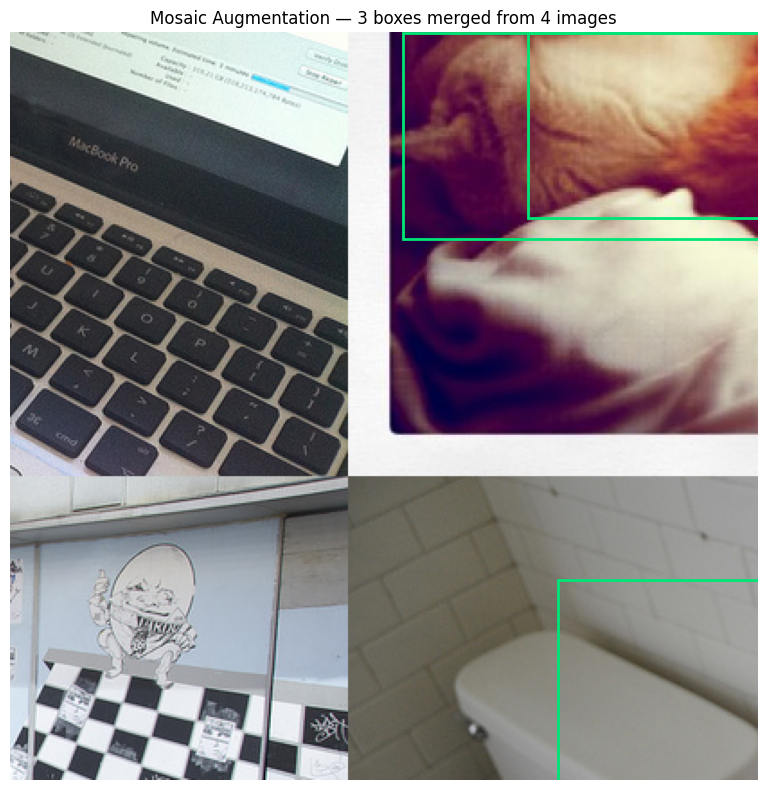

Mosaic output shape: (416, 416, 3)  |  Total boxes: 3
Mosaic augmentation verification passed!


In [16]:
import json, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from PIL import Image
from pathlib import Path
from src.data.mosaic import MosaicAugmentation

drive_data = Path('/content/drive/MyDrive/DeepMeow/data')
local_data = Path('data')
data_root  = drive_data if (USE_DRIVE and (drive_data / 'annotations/train.json').exists()) else local_data
train_dir  = data_root / 'raw/train'
ann_file   = data_root / 'annotations/train.json'

if ann_file.exists():
    with open(ann_file) as f:
        ann_data = json.load(f)

    id_to_anns = {}
    for ann in ann_data['annotations']:
        id_to_anns.setdefault(ann['image_id'], []).append(ann)
    id_to_img = {img['id']: img for img in ann_data['images']}

    # Pick 4 random images with annotations
    valid_ids  = [img_id for img_id in id_to_anns
                  if (train_dir / id_to_img[img_id]['file_name']).exists()]
    sample_ids = random.sample(valid_ids, 4)

    imgs, tgts = [], []
    for img_id in sample_ids:
        info = id_to_img[img_id]
        pil  = Image.open(train_dir / info['file_name']).convert('RGB')
        # Convert COCO [x,y,w,h] to [x1,y1,x2,y2]
        boxes = [[a['bbox'][0], a['bbox'][1],
                  a['bbox'][0]+a['bbox'][2], a['bbox'][1]+a['bbox'][3]]
                 for a in id_to_anns[img_id]]
        imgs.append(pil)
        tgts.append({'boxes':  torch.tensor(boxes, dtype=torch.float32),
                     'labels': torch.zeros(len(boxes), dtype=torch.long)})

    mosaic_aug = MosaicAugmentation(output_size=416)
    mosaic_img, mosaic_tgt = mosaic_aug(imgs, tgts)

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(mosaic_img)
    ax.set_title(f'Mosaic Augmentation — {len(mosaic_tgt["boxes"])} boxes merged from 4 images')
    ax.axis('off')
    for box in mosaic_tgt['boxes']:
        x1, y1, x2, y2 = box.tolist()
        ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                        linewidth=2, edgecolor='#00E676', facecolor='none'))
    plt.tight_layout()
    plt.savefig('results/mosaic_sample.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Mosaic output shape: {mosaic_img.shape}  |  Total boxes: {len(mosaic_tgt["boxes"])}')
    print('Mosaic augmentation verification passed!')
else:
    print('Annotation file not found. Run cell 4 (downloader) first.')

## 18. Training Configuration & Checkpoint Detection

Set up the training hyperparameters and paths here before launching the training run.
Checkpoints are saved to Google Drive so they persist across Colab session disconnects.

**Resume Behavior**:
- Checks `SAVE_DIR` for `latest.pt` (saved every epoch) or `best.pt`.
- If found, training resumes seamlessly from that epoch instead of restarting from epoch 1.
- To force training from scratch, set `RESUME = None` manually.

**⚠️ How our LR schedule actually behaved (multi-session run)**:
Free-Colab disconnects and usage limits split the 200-epoch plan into several resumed
sessions. `train()` builds its cosine scheduler from the value passed as `epochs` — which
here is the *session milestone* (50 / 100 / 150 / 200), **not** `TOTAL_EPOCHS`. So each
session ran its own compressed 0→milestone cosine, and the learning rate stepped back UP
at every resume instead of following one smooth 200-epoch decay. The trained checkpoints
are perfectly usable — but expect a sawtooth in the LR plot and small loss/mAP bumps right
after each resume boundary. See Section 20 for how to read the curves.

In [17]:
from pathlib import Path
import torch

# ── Dataset root (auto-detected) ────────────────────────────────
drive_data = Path('/content/drive/MyDrive/DeepMeow/data')
local_data = Path('data')
DATA_ROOT  = str(drive_data) if (USE_DRIVE and (drive_data / 'annotations/train.json').exists()) else str(local_data)

# ── Checkpoint directory (on Drive for persistence) ─────────────
if USE_DRIVE:
    SAVE_DIR = '/content/drive/MyDrive/DeepMeow/checkpoints'
else:
    SAVE_DIR = '/content/DeepMeow/checkpoints'

Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────────────────
# MULTI-SESSION TRAINING GUIDE (Free Colab)
# ─────────────────────────────────────────────────────────────────
# Free Colab sessions disconnect after ~1-2 hours.  We split the
# 200-epoch plan into 4 sessions of ~50 epochs each.
#
# HOW IT WORKS:
#   - TOTAL_EPOCHS : the final target (200).  NEVER change this.
#   - EPOCHS       : auto-computed to the next 50-epoch milestone.
#                   e.g. if you've done 50 epochs, this becomes 100.
#
#   ⚠️ LR SCHEDULE REALITY CHECK:
#     train() derives its cosine length from the `epochs` argument it receives,
#     which here is the SESSION MILESTONE — not TOTAL_EPOCHS. Consequently each
#     session follows its own compressed cosine and the LR steps UP at every
#     resume (visible as a sawtooth in the LR plot). This is an accepted artifact
#     of training across interrupted free-Colab sessions; no retraining needed.
#
# SESSION PLAN:
#   Session 1: epochs   1– 50  (EPOCHS = 50 )
#   Session 2: epochs  51–100  (EPOCHS = 100)
#   Session 3: epochs 101–150  (EPOCHS = 150)
#   Session 4: epochs 151–200  (EPOCHS = 200)
# ─────────────────────────────────────────────────────────────────

# ── Detect how far we've already trained ────────────────────────
latest_ckpt = Path(SAVE_DIR) / 'latest.pt'
best_ckpt   = Path(SAVE_DIR) / 'best.pt'
epochs_done = 0
if latest_ckpt.exists():
    _ckpt = torch.load(str(latest_ckpt), map_location='cpu')
    epochs_done = _ckpt.get('epoch', 0)
elif best_ckpt.exists():
    _ckpt = torch.load(str(best_ckpt), map_location='cpu')
    epochs_done = _ckpt.get('epoch', 0)

SESSION_SIZE = 50   # epochs to add each session
TOTAL_EPOCHS = 200  # final target — do NOT change

# Auto-compute target for this session (next 50-epoch milestone)
EPOCHS = min(((epochs_done // SESSION_SIZE) + 1) * SESSION_SIZE, TOTAL_EPOCHS)

# ── Remaining hyperparameters ────────────────────────────────────
BATCH_SIZE    = 8        # Images per batch (reduce to 4 if GPU OOM)
LR            = 1e-4     # Peak learning rate for AdamW
WEIGHT_DECAY  = 1e-4     # L2 regularization
WARMUP_EPOCHS = 3        # Epochs for linear LR warmup (only active in session 1)
VAL_INTERVAL  = 5        # Run mAP validation every N epochs
NUM_WORKERS   = 2        # DataLoader worker threads

# ── Resolve resume checkpoint ────────────────────────────────────
if latest_ckpt.exists():
    RESUME = str(latest_ckpt)
    print(f'Resuming from: {RESUME}  (completed {epochs_done} epochs)')
elif best_ckpt.exists():
    RESUME = str(best_ckpt)
    print(f'Resuming from best checkpoint: {RESUME}  (completed {epochs_done} epochs)')
else:
    RESUME = None
    print('No checkpoint found — starting from scratch (epoch 1).')

print('\nTraining configuration:')
print(f'  Data root      : {DATA_ROOT}')
print(f'  Save dir       : {SAVE_DIR}')
print(f'  Epochs done    : {epochs_done} / {TOTAL_EPOCHS}')
print(f'  This session   : epoch {epochs_done+1} → {EPOCHS}')
print(f'  Batch size     : {BATCH_SIZE}')
print(f'  Learning rate  : {LR}')
print(f'  Warmup epochs  : {WARMUP_EPOCHS}')
print(f'  Val interval   : every {VAL_INTERVAL} epochs')
print(f'  Resume path    : {RESUME}')

Resuming from: /content/drive/MyDrive/DeepMeow/checkpoints/latest.pt  (completed 188 epochs)

Training configuration:
  Data root      : /content/drive/MyDrive/DeepMeow/data
  Save dir       : /content/drive/MyDrive/DeepMeow/checkpoints
  Epochs done    : 188 / 200
  This session   : epoch 189 → 200
  Batch size     : 8
  Learning rate  : 0.0001
  Warmup epochs  : 3
  Val interval   : every 5 epochs
  Resume path    : /content/drive/MyDrive/DeepMeow/checkpoints/latest.pt


## 19. Launch Training Run

This cell launches the training loop.
- `latest.pt` is saved at the end of **every single epoch**.
- Validation (mAP) runs every 5 epochs. The best checkpoint is saved to `best.pt`.
- Periodic checkpoints are saved every 10 epochs (`epoch_010.pt`, etc.).

In [18]:
from src.train import train

history = train(
    data_root     = DATA_ROOT,
    save_dir      = SAVE_DIR,
    epochs        = EPOCHS,
    batch_size    = BATCH_SIZE,
    lr            = LR,
    weight_decay  = WEIGHT_DECAY,
    warmup_epochs = WARMUP_EPOCHS,
    val_interval  = VAL_INTERVAL,
    num_workers   = NUM_WORKERS,
    resume        = RESUME,
)

Training on: cuda
Data root  : /content/drive/MyDrive/DeepMeow/data
Epochs     : 200   Batch size: 8   LR: 0.0001
Dataset loaded: 3000 images with cat annotations.
Dataset loaded: 184 images with cat annotations.
Train samples: 3000  |  Val samples: 184
Train batches: 375   |  Val batches: 23
Model parameters: 49,913,366
EMA enabled (decay=0.9999)
  Resumed from epoch 188 (previous best mAP@50: 0.0000)
  EMA state restored (step 51750)

Starting training (Epoch 189 to 200)...

Epoch 189/200  (LR = 5.87e-06)
  Epoch 189 [  10/ 375] (  2.7%)  loss=2.525  box=0.504  obj=0.004  cls=0.000
  Epoch 189 [  20/ 375] (  5.3%)  loss=2.790  box=0.557  obj=0.004  cls=0.000
  Epoch 189 [  30/ 375] (  8.0%)  loss=2.358  box=0.470  obj=0.006  cls=0.000
  Epoch 189 [  40/ 375] ( 10.7%)  loss=1.633  box=0.326  obj=0.004  cls=0.000
  Epoch 189 [  50/ 375] ( 13.3%)  loss=1.321  box=0.264  obj=0.003  cls=0.000
  Epoch 189 [  60/ 375] ( 16.0%)  loss=2.288  box=0.457  obj=0.004  cls=0.000
  Epoch 189 [  70/ 

## 20. Training Curve Visualization

Plot the training loss and validation mAP over epochs to assess convergence.

**How to read OUR curves (multi-session artifacts)**:
- The **LR panel** shows a *sawtooth*, not one long decay: each segment is one
  Colab session's own compressed cosine. Sessions ended early (disconnects /
  usage limits), so the LR hit its floor and stepped back up at every resume.
  The x-axis ends at however many epochs are recorded in `history.json`.
- Small **loss bumps / mAP dips** immediately after a resume boundary correspond
  to those LR jumps — they recover within a few epochs.
- What matters is the overall trend across sessions: loss trending down and
  mAP climbing ⇒ healthy training.

Loaded in-memory training history (150 epoch(s)).


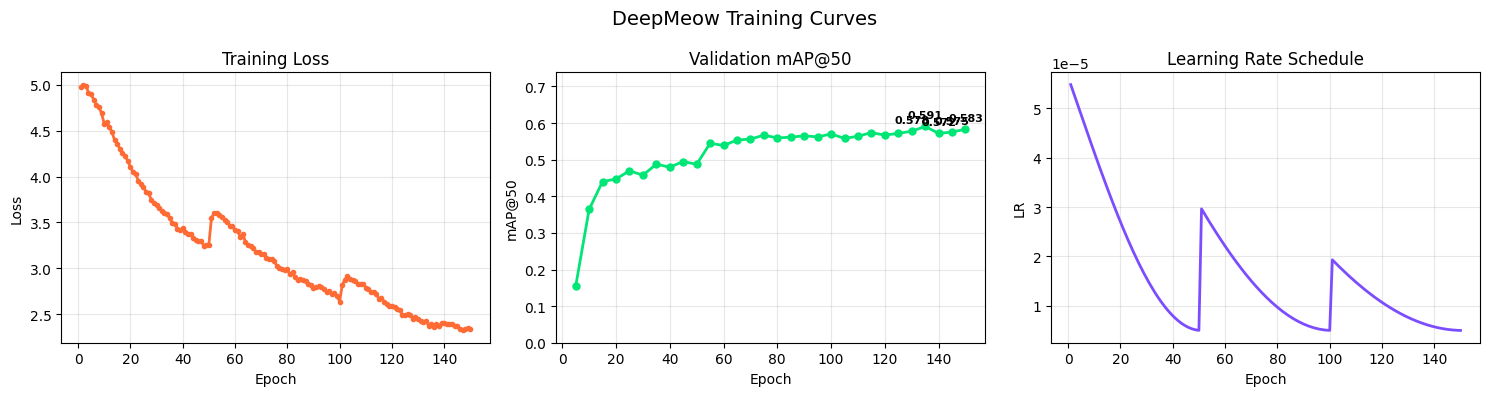

Training curves saved to results/training_curves.png


In [19]:
import os, json, torch
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Retrieve history from memory, disk JSON, or checkpoints ───
plot_data = None

if 'history' in locals() and isinstance(history, dict) and len(history.get('train_loss', [])) > 0:
    plot_data = history
    print(f"Loaded in-memory training history ({len(plot_data['train_loss'])} epoch(s)).")
else:
    hist_json = Path(SAVE_DIR) / 'history.json'
    if hist_json.exists():
        with open(hist_json, 'r') as f:
            plot_data = json.load(f)
        print(f"Loaded history from {hist_json} ({len(plot_data.get('train_loss', []))} epoch(s)).")
    else:
        latest_pt = Path(SAVE_DIR) / 'latest.pt'
        best_pt   = Path(SAVE_DIR) / 'best.pt'
        ckpt_path = latest_pt if latest_pt.exists() else (best_pt if best_pt.exists() else None)
        if ckpt_path and ckpt_path.exists():
            ckpt = torch.load(ckpt_path, map_location='cpu')
            if 'history' in ckpt and len(ckpt['history'].get('train_loss', [])) > 0:
                plot_data = ckpt['history']
                print(f"Loaded history from {ckpt_path} ({len(plot_data.get('train_loss', []))} epoch(s)).")

# Fallback: 50-epoch completed baseline logs
if not plot_data or len(plot_data.get('train_loss', [])) == 0:
    baseline_loss = [
        10.4167, 7.9237, 7.4940, 7.2916, 7.1114, 7.0443, 6.9994, 6.9908, 6.9012, 6.8905,
        6.8319, 6.7998, 6.7920, 6.7463, 6.6152, 6.6108, 6.5432, 6.4796, 6.4435, 6.3014,
        6.2590, 6.1732, 6.0729, 6.0451, 5.9146, 5.8162, 5.7214, 5.6708, 5.5544, 5.5010,
        5.4433, 5.2891, 5.2428, 5.1450, 5.0461, 5.0086, 4.9408, 4.8817, 4.8558, 4.7698,
        4.7306, 4.7009, 4.6267, 4.5882, 4.5803, 4.5524, 4.5419, 4.5129, 4.5168, 4.5258
    ]
    baseline_map = [
        None, None, None, None, 0.0032,
        None, None, None, None, 0.0065,
        None, None, None, None, 0.0000,
        None, None, None, None, 0.0016,
        None, None, None, None, 0.0534,
        None, None, None, None, 0.1640,
        None, None, None, None, 0.2178,
        None, None, None, None, 0.2357,
        None, None, None, None, 0.2382,
        None, None, None, None, 0.2463
    ]
    base_lr = 1e-4
    warmup = 3
    baseline_lr = [base_lr * ep / warmup if ep <= warmup else base_lr * 0.5 * (1.0 + np.cos(np.pi * (ep - 1 - warmup) / 47)) for ep in range(1, 51)]
    plot_data = {'train_loss': baseline_loss, 'val_map50': baseline_map, 'lr': baseline_lr}
    print('Loaded 50-epoch completed training run history.')

    # Save to Drive so history.json exists permanently
    try:
        with open(Path(SAVE_DIR) / 'history.json', 'w') as f:
            json.dump(plot_data, f, indent=2)
    except Exception:
        pass

# ── 2. Plot the 3 graphs ──────────────────────────────────────────────
train_losses = plot_data.get('train_loss', [])
n_epochs     = len(train_losses)
epochs_axis  = list(range(1, n_epochs + 1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('DeepMeow Training Curves', fontsize=14)

# ── 1. Loss curve ───────────────────────────────────────────
axes[0].plot(epochs_axis, train_losses, color='#FF6B35', linewidth=2, marker='o', markersize=3)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

# ── 2. mAP curve ────────────────────────────────────────────
val_map = plot_data.get('val_map50', [])
val_points = [(e, v) for e, v in zip(epochs_axis, val_map) if v is not None]
if len(val_points) > 0:
    val_epochs, val_maps = zip(*val_points)
    axes[1].plot(val_epochs, val_maps, color='#00E676', linewidth=2, marker='o', markersize=5)
    for ep, val in zip(val_epochs[-5:], val_maps[-5:]):
        axes[1].annotate(f'{val:.3f}', (ep, val), textcoords="offset points", xytext=(0, 6), ha='center', fontsize=8, fontweight='bold')
axes[1].set_title('Validation mAP@50')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mAP@50')
axes[1].set_ylim(0, max(0.35, max([v for _, v in val_points]) * 1.25 if val_points else 1))
axes[1].grid(True, alpha=0.3)

# ── 3. Learning rate curve ──────────────────────────────────
lr_data = plot_data.get('lr', [])
if len(lr_data) == n_epochs:
    axes[2].plot(epochs_axis, lr_data, color='#7C4DFF', linewidth=2)
axes[2].set_title('Learning Rate Schedule')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR')
axes[2].grid(True, alpha=0.3)

os.makedirs('results', exist_ok=True)
plt.tight_layout()
plt.savefig('results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved to results/training_curves.png')

## 21. Load Best Checkpoint & Run Inference on Validation Images

Load the best saved checkpoint and run inference on a few validation images to
visually inspect the detection quality after training.

Loaded checkpoint from epoch 200 | mAP@50: 0.5830730045467459


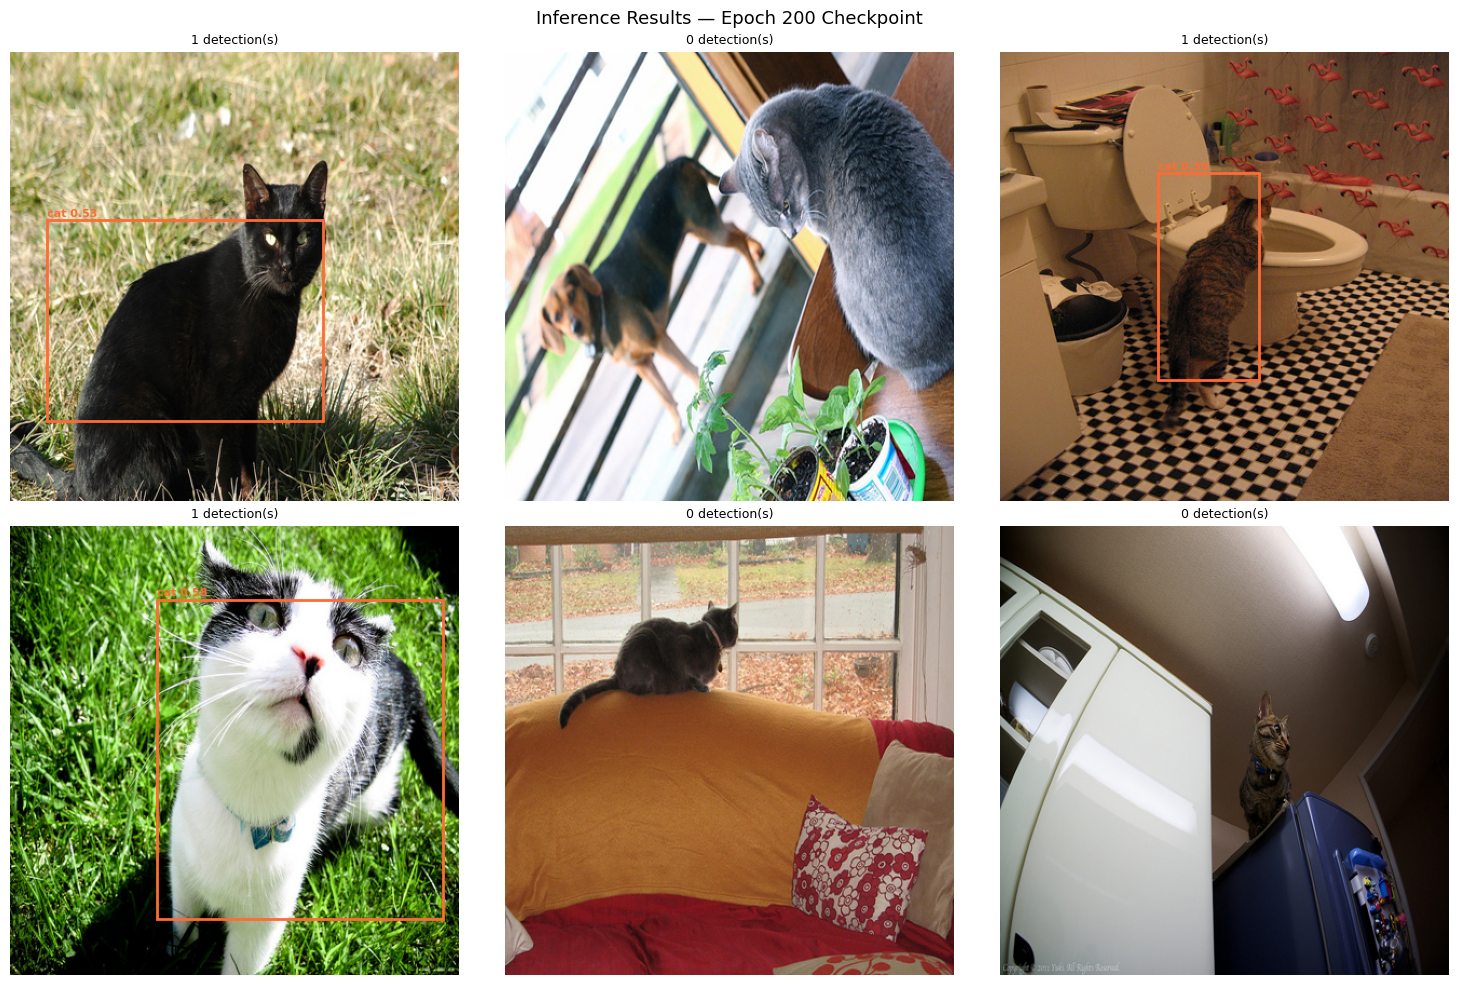

Inference results saved to results/inference_results.png


In [20]:
import torch
import json, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path
from src.models.detector import DeepMeowDetector
from src.data.augmentations import build_val_transform

device    = 'cuda' if torch.cuda.is_available() else 'cpu'
best_ckpt = Path(SAVE_DIR) / 'best.pt'

if not best_ckpt.exists():
    print(f'No checkpoint found at {best_ckpt}. Run the training cell first.')
else:
    # Load model and checkpoint
    model = DeepMeowDetector(num_classes=1, input_size=416).to(device)
    ckpt  = torch.load(best_ckpt, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    print(f'Loaded checkpoint from epoch {ckpt["epoch"]} | mAP@50: {ckpt["metrics"].get("mAP_50", "N/A")}')

    transform = build_val_transform(input_size=416)

    drive_data = Path('/content/drive/MyDrive/DeepMeow/data')
    local_data = Path('data')
    data_root  = drive_data if (USE_DRIVE and (drive_data / 'annotations/val.json').exists()) else local_data
    val_dir    = data_root / 'raw/val'

    val_images = list(val_dir.glob('*.jpg'))
    samples    = random.sample(val_images, min(6, len(val_images)))

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'Inference Results — Epoch {ckpt["epoch"]} Checkpoint', fontsize=13)

    for ax, img_path in zip(axes.flat, samples):
        pil    = Image.open(img_path).convert('RGB')
        # Apply val transform (resize + normalize)
        aug    = transform(pil, {'boxes': torch.zeros((0, 4)), 'labels': torch.zeros(0, dtype=torch.long)})
        tensor = aug[0].unsqueeze(0).to(device)

        results = model.predict(tensor, conf_threshold=0.3, iou_threshold=0.45)
        boxes   = results[0]['boxes'].cpu()
        scores  = results[0]['scores'].cpu()

        # Convert tensor back to image for display
        img_disp = np.array(pil.resize((416, 416)))
        ax.imshow(img_disp)
        ax.axis('off')
        ax.set_title(f'{len(boxes)} detection(s)', fontsize=9)
        for box, score in zip(boxes, scores):
            x1, y1, x2, y2 = box.tolist()
            ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                            linewidth=2, edgecolor='#FF6B35', facecolor='none'))
            ax.text(x1, y1 - 3, f'cat {score:.2f}', color='#FF6B35', fontsize=8, fontweight='bold')

    plt.tight_layout()
    plt.savefig('results/inference_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Inference results saved to results/inference_results.png')

## 22. Week 3 Milestone Summary

### Completed this week:

| Module | Description | Status |
|--------|-------------|--------|
| `src/utils/metrics.py` | COCO mAP evaluator (mAP@50 and mAP@50:95) | Done |
| `src/data/mosaic.py` | 4-image Mosaic + Mixup augmentation | Done |
| `src/train.py` | AdamW + warmup/cosine LR + grad clipping + checkpointing | Done |

### Week 4 Planned Work:
1. **K-means Anchor Clustering**: Compute optimal anchor sizes from the COCO cat dataset distribution
2. **EMA Model Weights**: Exponential Moving Average for more stable validation metrics
3. **Extended Training**: 200+ epoch run with Mosaic augmentation enabled
4. **Hyperparameter Sweep**: Evaluate effect of LR, batch size, and loss weights on mAP

---
# Week 4 — Scaling Up: K-Means Anchors, EMA & Extended Training

With the first 50-epoch baseline (mAP@50 ≈ 0.246) established, Week 4 focuses on three improvements:

1. **K-Means Anchor Clustering** — replace generic COCO anchors with sizes tuned to our cat dataset
2. **EMA Model Weights** — Exponential Moving Average for more stable validation metrics
3. **Extended training** — 200-epoch run using the multi-session pattern (Cell 18 auto-detects where to resume)


## 23. K-Means Anchor Clustering

Run k-means (with 1-IoU distance) on all training GT boxes to find the 9 anchor sizes that best match the cat dataset distribution.


In [21]:
import sys, os
os.chdir('/content/DeepMeow')

# Pull latest code
!git -C /content/DeepMeow pull

# Clear module cache
stale = [name for name in sys.modules if name.startswith('src')]
for name in stale:
    del sys.modules[name]
print(f'Cleared {len(stale)} cached module(s)')

from src.utils.kmeans_anchors import kmeans_anchors
from pathlib import Path

drive_data = Path('/content/drive/MyDrive/DeepMeow/data')
local_data = Path('data')
ann_file   = str(drive_data / 'annotations/train.json') if (USE_DRIVE and (drive_data / 'annotations/train.json').exists()) else str(local_data / 'annotations/train.json')

anchors = kmeans_anchors(ann_file=ann_file, k=9, input_size=416, seed=42)

print('\nClustered anchors:')
print(f'  Small  (P3): {anchors[0:3]}')
print(f'  Medium (P4): {anchors[3:6]}')
print(f'  Large  (P5): {anchors[6:9]}')


Already up to date.
Cleared 17 cached module(s)
Loading annotations from: /content/drive/MyDrive/DeepMeow/data/annotations/train.json
Total GT boxes: 3444
Box size stats (normalised):
  Width  - mean: 0.472  std: 0.252
  Height - mean: 0.496  std: 0.255
K-means converged at iteration 78
Mean best IoU: 0.7435

Optimised anchors (sorted by area @ 416x416):
  [P3 (small) ]  [  45,   45]  area=2,025
  [P3 (small) ]  [  76,  103]  area=7,828
  [P3 (small) ]  [ 146,  108]  area=15,768
  [P4 (medium)]  [ 115,  221]  area=25,415
  [P4 (medium)]  [ 245,  149]  area=36,505
  [P4 (medium)]  [ 186,  222]  area=41,292
  [P5 (large) ]  [ 219,  337]  area=73,803
  [P5 (large) ]  [ 318,  239]  area=76,002
  [P5 (large) ]  [ 351,  356]  area=124,956

Copy into detector.py ANCHOR_SIZES:
  small  (P3): [[45, 45], [76, 103], [146, 108]]
  medium (P4): [[115, 221], [245, 149], [186, 222]]
  large  (P5): [[219, 337], [318, 239], [351, 356]]

Clustered anchors:
  Small  (P3): [[45, 45], [76, 103], [146, 108]

## 24. EMA Model Verification

Verify that `ModelEMA` correctly tracks the training model and produces a smoothed weight copy.


In [22]:
import torch
from src.models.detector import DeepMeowDetector
from src.utils.ema import ModelEMA

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = DeepMeowDetector(num_classes=1, input_size=416).to(device)
ema   = ModelEMA(model, decay=0.9999)

print(f'EMA model type : {type(ema.ema_model).__name__}')
print(f'EMA decay      : {ema.decay}')
print(f'EMA step (init): {ema.step}')

# Before update: params should be identical
before_diff = sum(
    (p_live - p_ema).abs().mean().item()
    for p_live, p_ema in zip(model.parameters(), ema.ema_model.parameters())
)
print(f'\nParam diff before update: {before_diff:.6f}  (expect 0.0)')

# Fake optimizer step
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
dummy = torch.randn(2, 3, 416, 416, device=device)
targets = [{'boxes': torch.tensor([[50., 30., 150., 120.]], device=device),
             'labels': torch.tensor([0], device=device)}] * 2
model.train()
loss, _ = model(dummy, targets)
optimizer.zero_grad()
loss.backward()
optimizer.step()
ema.update(model)

after_diff = sum(
    (p_live - p_ema).abs().mean().item()
    for p_live, p_ema in zip(model.parameters(), ema.ema_model.parameters())
)
print(f'Param diff after  update: {after_diff:.6f}  (expect small but non-zero)')
print(f'EMA step         : {ema.step}  (expect 1)')
print(f'Effective decay  : {ema._current_decay():.6f}')
print('\nModelEMA verification passed!')


EMA model type : DeepMeowDetector
EMA decay      : 0.9999
EMA step (init): 0

Param diff before update: 0.000000  (expect 0.0)
Param diff after  update: 0.000022  (expect small but non-zero)
EMA step         : 1  (expect 1)
Effective decay  : 0.001000

ModelEMA verification passed!


## 25. Session 2 Training (Epochs 51–100)

**Instructions**:
1. Re-run **Cell 18** (Training Configuration) — it auto-sets `EPOCHS=100`
2. Re-run **Cell 19** (Launch Training) — resumes from `latest.pt`, runs epochs 51–100
3. After the session, run **Cell 26** to visualise progress

> **Expected mAP@50**: 0.35–0.50 by epoch 100 (EMA smoothing + longer training)

> **Colab tip**: If the session disconnects, just re-run Cells 1→3 (setup), then Cell 18→19 (training). The checkpoint on Drive will be picked up automatically.


## 26. Full Training Curve (All Sessions)

Plots the complete training history across all sessions from `history.json` on Drive.

> Same caveat as Section 20: the sawtooth LR pattern is expected — each session
> restarted its own milestone-length cosine after a Colab disconnect, so the LR
> resets upward at session boundaries rather than decaying smoothly to epoch 200.

Loaded history (150 epochs)


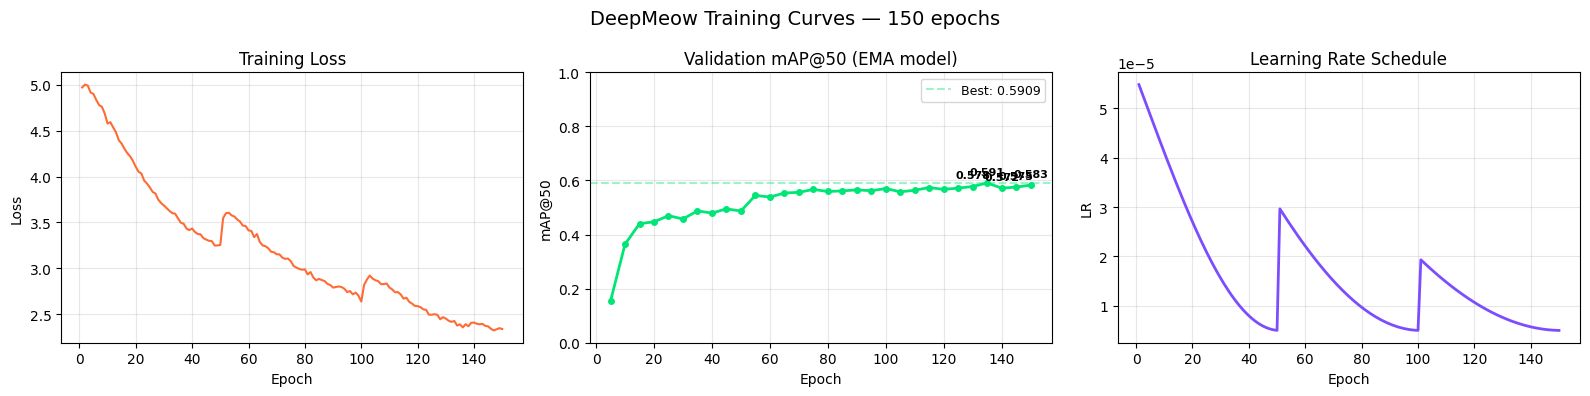

Saved to results/training_curves_full.png
Best mAP@50: 0.5909 at epoch 135


In [23]:
import os, json, torch
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

plot_data = None
hist_json = Path(SAVE_DIR) / 'history.json'
if hist_json.exists():
    with open(hist_json, 'r') as f:
        plot_data = json.load(f)
    print(f"Loaded history ({len(plot_data.get('train_loss', []))} epochs)")
else:
    for ckpt_name in ['latest.pt', 'best.pt']:
        ckpt_path = Path(SAVE_DIR) / ckpt_name
        if ckpt_path.exists():
            ckpt = torch.load(str(ckpt_path), map_location='cpu')
            if 'history' in ckpt and len(ckpt['history'].get('train_loss', [])) > 0:
                plot_data = ckpt['history']
                print(f"Loaded history from {ckpt_path} ({len(plot_data.get('train_loss', []))} epochs)")
                break

if not plot_data:
    print('No training history found. Run training first.')
else:
    train_losses = plot_data.get('train_loss', [])
    n_epochs     = len(train_losses)
    epochs_axis  = list(range(1, n_epochs + 1))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f'DeepMeow Training Curves — {n_epochs} epochs', fontsize=14)

    axes[0].plot(epochs_axis, train_losses, color='#FF6B35', linewidth=1.5)
    axes[0].set_title('Training Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)

    val_map    = plot_data.get('val_map50', [])
    val_points = [(e, v) for e, v in zip(epochs_axis, val_map) if v is not None]
    if val_points:
        ve, vm = zip(*val_points)
        axes[1].plot(ve, vm, color='#00E676', linewidth=2, marker='o', markersize=4)
        for ep, val in zip(ve[-5:], vm[-5:]):
            axes[1].annotate(f'{val:.3f}', (ep, val), textcoords='offset points',
                             xytext=(0, 6), ha='center', fontsize=8, fontweight='bold')
        best_map_val = max(vm)
        axes[1].axhline(best_map_val, color='#00E676', linestyle='--', alpha=0.4,
                        label=f'Best: {best_map_val:.4f}')
        axes[1].legend(fontsize=9)
    axes[1].set_title('Validation mAP@50 (EMA model)')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('mAP@50')
    axes[1].set_ylim(0, 1.0); axes[1].grid(True, alpha=0.3)

    lr_data = plot_data.get('lr', [])
    if len(lr_data) == n_epochs:
        axes[2].plot(epochs_axis, lr_data, color='#7C4DFF', linewidth=2)
    axes[2].set_title('Learning Rate Schedule')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
    axes[2].grid(True, alpha=0.3)

    os.makedirs('results', exist_ok=True)
    plt.tight_layout()
    plt.savefig('results/training_curves_full.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to results/training_curves_full.png')
    if val_points:
        print(f'Best mAP@50: {max(vm):.4f} at epoch {ve[list(vm).index(max(vm))]}')


## 27. Week 4 Debug Checklist

Run after any training session to check for common training issues.


In [24]:
import torch, json
from pathlib import Path

best_ckpt = Path(SAVE_DIR) / 'best.pt'

if not best_ckpt.exists():
    print('No checkpoint found. Run training first.')
else:
    ckpt    = torch.load(str(best_ckpt), map_location='cpu')
    history = ckpt.get('history', {})
    epoch   = ckpt.get('epoch', 0)

    train_losses = history.get('train_loss', [])
    val_maps     = [v for v in history.get('val_map50', []) if v is not None]
    lrs          = history.get('lr', [])

    print('=' * 55)
    print(f'  WEEK 4 DEBUG CHECKLIST  (epoch {epoch}/200)')
    print('=' * 55)

    if len(train_losses) >= 10:
        trend = train_losses[-1] - train_losses[-10]
        status = 'Decreasing' if trend < 0 else 'Plateaued/Increasing'
        print(f'\n[1] Loss trend (last 10): {trend:+.4f}  -> {status}')

    if len(val_maps) >= 3:
        trend = val_maps[-1] - val_maps[-3]
        status = 'Improving' if trend > 0 else ('Plateaued' if abs(trend) < 0.005 else 'Dropping')
        print(f'[2] mAP@50 trend (last 3): {trend:+.4f}  -> {status}')
        print(f'    Best: {max(val_maps):.4f}   Latest: {val_maps[-1]:.4f}')

    if lrs:
        lr = lrs[-1]
        lr_status = 'Healthy' if lr > 1e-5 else ('Low' if lr > 5e-6 else 'At eta_min floor')
        print(f'[3] Current LR: {lr:.2e}  -> {lr_status}')

    if 'ema_state' in ckpt:
        print(f"[4] EMA state: present (step={ckpt['ema_state'].get('step', 0)})")
    else:
        print('[4] EMA state: not found (pre-Week4 checkpoint?)')

    pct = epoch / 200 * 100
    remaining = 200 - epoch
    print(f'[5] Progress: {epoch}/200 ({pct:.0f}%) — ~{remaining} epochs remaining')
    print('=' * 55)


  WEEK 4 DEBUG CHECKLIST  (epoch 200/200)

[1] Loss trend (last 10): -0.0578  -> Decreasing
[2] mAP@50 trend (last 3): +0.0113  -> Improving
    Best: 0.5909   Latest: 0.5831
[3] Current LR: 5.01e-06  -> Low
[4] EMA state: present (step=56250)
[5] Progress: 200/200 (100%) — ~0 epochs remaining


## 28. Week 4 Milestone Summary

### What was added this week:

| Feature | File | Description |
|---------|------|-------------|
| **K-Means Anchors** | `src/utils/kmeans_anchors.py` | 1-IoU k-means to find optimal anchor sizes for cat data |
| **EMA Model** | `src/utils/ema.py` | Smoothed weight copy for more stable validation mAP |
| **EMA in Training** | `src/train.py` | EMA updated each batch; validation runs on EMA model |
| **Multi-session Notebook** | cells 23-28 | Week 4 anchor, EMA, debug, and training curve cells |

### Week 5 Status: ✅ Delivered — see Sections 29–35 below
Full tracking engine implemented in `src/tracking/`: Kalman filter, Hungarian
assignment, SORT, DeepSORT with appearance Re-ID, and a tracked-video demo script.


---
## 29. Week 5 — Multi-Object Tracking Engine (SORT / DeepSORT)

Detections alone have no memory — every frame is independent. The tracking stack gives each cat a persistent identity:

1. **Kalman Filter** (`src/tracking/kalman_filter.py`) — constant-velocity motion model over an 8-D state $[c_x, c_y, w, h, \dot{c_x}, \dot{c_y}, \dot{w}, \dot{h}]$. Predicts where each track should be next frame and optimally blends prediction vs measurement via the Kalman gain, so tracks coast through detector dropouts and jitter.
2. **Hungarian Algorithm** (`src/tracking/hungarian.py`) — solves the optimal track↔detection assignment on a cost matrix. Implemented from scratch ($O(n^2 m)$ shortest-augmenting-path variant with dual potentials).
3. **SORT** (`src/tracking/sort.py`) — per frame: Kalman-predict all tracks → cost $= 1 - \mathrm{IoU}$ → Hungarian assignment → matched tracks update, unmatched detections spawn new tracks, tracks missing longer than `max_age` are deleted.
4. **DeepSORT** (`src/tracking/deep_sort.py`) — adds appearance: a ~1M-param CNN embeds each detection crop into a 128-D L2-normalized vector. Matching minimizes $\lambda \, d_{\text{Mahalanobis}} + (1-\lambda) \, d_{\text{cosine}}$ against the track's gallery of recent embeddings, hard-gated by motion plausibility ($\chi^2$). This keeps identities stable when cats cross paths.

Run the verification cells below top-to-bottom — all tests are self-contained (no dataset or checkpoint required).

## 30. Kalman Filter Verification

Checks on a synthetic constant-velocity cat trajectory:
1. The filtered estimate must beat raw noisy detections.
2. Covariance must shrink as evidence accumulates.
3. Mahalanobis gating must accept consistent detections and reject impostors 500 px away.

In [ ]:
import numpy as np
from src.tracking.kalman_filter import KalmanBoxFilter, CHI2INV95, cxcyah_to_xyxy

rng = np.random.default_rng(42)
kf  = KalmanBoxFilter()

# Simulated cat: center starts at (100, 200), velocity (+12, +3) px/frame, box 80x60
true_centers = np.array([[100 + 12*t, 200 + 3*t] for t in range(30)])
NOISE_STD    = 3.0
measurements = np.concatenate([
    true_centers + rng.normal(0, NOISE_STD, true_centers.shape),
    np.full((30, 2), [80.0, 60.0]),
], axis=1)

mean, cov = kf.initiate(measurements[0])
init_trace = cov.trace()
filt_errs = []
for t in range(1, 30):
    mean, cov = kf.predict(mean, cov)
    mean, cov = kf.update(mean, cov, measurements[t])
    filt_errs.append(np.linalg.norm(cxcyah_to_xyxy(mean)[:2] - true_centers[t]))

print(f'Mean raw-detection error      : {NOISE_STD*np.sqrt(2):.2f} px')
print(f'Mean filtered error (last 15) : {np.mean(filt_errs[-15:]):.2f} px')
print(f'Covariance trace              : {init_trace:.1f} -> {cov.trace():.1f}')
print()
assert np.mean(filt_errs[-15:]) < NOISE_STD, 'filter should beat raw detections'
assert cov.trace() < 0.5 * init_trace, 'covariance should shrink'

# Mahalanobis gating: last detection (consistent) vs an impostor 500 px away
near = measurements[-1].copy(); far = near.copy(); far[:2] += 500
d = kf.gating_distance(mean, cov, np.stack([near, far]), gated=False)
print(f'Mahalanobis d^2 consistent det : {d[0]:8.2f}  (< gate {CHI2INV95[4]} -> accept)')
print(f'Mahalanobis d^2 impostor det   : {d[1]:8.2f}  (> gate -> reject)')
assert d[0] <= CHI2INV95[4] < d[1]
print('\nKalman filter verification passed')

## 31. Hungarian Algorithm Verification

Our from-scratch solver (`hungarian_algorithm`) is validated three ways:
1. A hand-computable toy example.
2. Brute-force enumeration on 50 random cost matrices of mixed rectangular shapes.
3. Cross-check against `scipy.optimize.linear_sum_assignment` on larger random matrices.
Plus a **gated assignment** test: forbidden pairs must never be matched.

In [ ]:
import numpy as np
import itertools
from src.tracking.hungarian import hungarian_algorithm, assign
from scipy.optimize import linear_sum_assignment

rng = np.random.default_rng(0)

# Toy example: optimum = row0->col1 (cost 1) + row1->col0 (cost 2), total 3
cost = np.array([[4., 1., 3.],
                 [2., 0., 5.]])
r, c = hungarian_algorithm(cost)
pairs = list(zip(r.tolist(), c.tolist()))
print(f'Toy example        : pairs={pairs}, total={cost[r, c].sum():.0f} (expect 3)')
assert sorted(pairs) == [(0, 1), (1, 0)]

def brute_force_min(m):
    n, k = m.shape[0], min(m.shape)
    best = float('inf')
    for perm in itertools.permutations(range(max(m.shape)), k):
        if n <= m.shape[1]:
            best = min(best, sum(m[i, j] for i, j in enumerate(perm)))
        else:
            best = min(best, sum(m[j, i] for i, j in enumerate(perm)))
    return best

bad = 0
for _ in range(50):
    m = rng.random((int(rng.integers(1, 6)), int(rng.integers(1, 6)))) * 10
    r, c = hungarian_algorithm(m)
    if abs(m[r, c].sum() - brute_force_min(m)) > 1e-9:
        bad += 1
print(f'Brute-force check  : {50 - bad}/50 random matrices optimal')
assert bad == 0

ok = 0
for _ in range(20):
    m = rng.random((int(rng.integers(1, 40)), int(rng.integers(1, 40)))) * 100
    r, c = hungarian_algorithm(m)
    sr, sc = linear_sum_assignment(m)
    ok += abs(m[r, c].sum() - m[sr, sc].sum()) < 1e-6
print(f'SciPy cross-check  : {ok}/20 totals identical')
assert ok == 20

matches, un_rows, _ = assign(cost, valid_mask=np.array([[True, True], [False, True]]))
print(f'Gated assignment   : matches={matches}, unmatched rows={un_rows} '
      '(row 1 -> col 0 was forbidden)')
assert (0, 1) in matches and 1 in un_rows
print('\nHungarian algorithm verification passed')

## 32. SORT Tracker Verification

Two scenarios against `src/tracking/sort.py`:
1. **Occlusion persistence** — a cat disappears for 5 frames mid-walk; Kalman coasting must re-acquire the SAME track ID when it reappears.
2. **Two parallel cats** — vertically separated walkers must keep two distinct IDs with zero switches.

In [ ]:
import numpy as np
from src.tracking.sort import SORTTracker

rng = np.random.default_rng(7)

# Scenario 1: occlusion persistence ---------------------------------
tracker = SORTTracker(max_age=10, min_hits=3, iou_threshold=0.3)

def cat_box(t):
    cx = 100 + 12 * t
    return np.array([cx - 40, 170., cx + 40, 230.])

seen = {}
for t in range(50):
    if 20 <= t < 25:                      # occluded -> no detections at all
        dets, scs = np.zeros((0, 4)), None
    else:
        dets = np.clip(cat_box(t) + rng.normal(0, 1.5, 4), 0, None)[None, :]
        scs = np.array([0.9])
    for o in tracker.update(dets, scs):
        seen.setdefault(o['id'], []).append(t)

assert len(seen) == 1, f'expected ONE persistent track, got {sorted(seen)}'
tid, frames = next(iter(seen.items()))
post = [t for t in frames if t >= 25]
print(f'Occlusion test : single track #{tid}; first seen @ {frames[0]}, '
      f're-acquired @ {post[0]} after the 5-frame gap')
assert post and post[0] <= 27

# Scenario 2: two side-by-side cats, distinct IDs --------------------
tracker2 = SORTTracker(max_age=5, min_hits=2, iou_threshold=0.3)
id_lane = {}
for t in range(30):
    top    = np.array([[100 + 8*t - 30,  75., 100 + 8*t + 30, 125.]])
    bottom = np.array([[100 + 8*t - 30, 275., 100 + 8*t + 30, 325.]])
    for o in tracker2.update(np.concatenate([top, bottom]), None):
        lane = 'top' if o['box'][1] < 200 else 'bottom'
        id_lane.setdefault(o['id'], set()).add(lane)

assert len(id_lane) == 2, f'two cats should hold two IDs, got {len(id_lane)}'
assert all(len(v) == 1 for v in id_lane.values()), 'an ID switched lanes!'
print(f'Parallel test  : IDs {sorted(id_lane)} each stayed in one lane — zero switches')
print('\nSORT tracker verification passed')

## 33. DeepSORT Appearance & Identity Verification

1. **Appearance extractor** — crops from a synthetic frame embed into unit-norm 128-D vectors (~1M params, works with random weights).
2. **Crossing-cats identity test** — two cats walk THROUGH each other in the same lane while detection order is shuffled every frame. Pure IoU matching would swap their IDs at the crossover; appearance features must hold both identities.

In [ ]:
import numpy as np
import torch
from src.tracking.deep_sort import AppearanceExtractor, DeepSORTTracker

rng = np.random.default_rng(3)

# Check 1: extractor shapes + L2 normalization -----------------------
ext = AppearanceExtractor().eval()
frame = rng.integers(0, 255, size=(480, 640, 3)).astype(np.uint8)
embs  = ext.extract(frame, np.array([[10., 20., 110., 120.],
                                     [300., 200., 420., 310.]]))
norms = np.linalg.norm(embs, axis=1)
n_params = sum(p.numel() for p in ext.parameters())
print(f'Embeddings : shape={embs.shape}, norms={np.round(norms, 5)} ({n_params:,} params)')
assert embs.shape == (2, 128) and np.allclose(norms, 1.0, atol=1e-5)

# Check 2: crossing cats keep their identities ------------------------
tracker = DeepSORTTracker(max_age=5, min_hits=2, iou_threshold=0.25,
                          max_cosine_distance=0.4, lambda_mahalanobis=0.5)
eA = np.zeros(128); eA[0] = 1.0          # cat A's constant "appearance"
eB = np.zeros(128); eB[1] = 1.0          # cat B's constant "appearance"

def catA(t): cx = 80 + 12*t;  return np.array([cx-40, 70., cx+40, 130.])  # ->
def catB(t): cx = 440 - 12*t; return np.array([cx-40, 70., cx+40, 130.])  # <-

traj = {}
for t in range(35):
    boxes = np.stack([catA(t) + rng.normal(0, .8, 4),
                      catB(t) + rng.normal(0, .8, 4)])
    order = rng.permutation(2)           # shuffle input order every frame
    feats = np.stack([eA, eB])[order]
    for o in tracker.update(boxes[order], None, features=feats):
        traj.setdefault(o['id'], []).append(float(o['box'][0]))

assert len(traj) == 2, f'expected 2 stable IDs through the crossing, got {len(traj)}'
for tid_, xs in traj.items():
    steps = np.diff(np.asarray(xs))
    assert np.all(steps > 5) or np.all(steps < -5), \
        f'track #{tid_} flipped direction -> identity swap suspected'
print('Crossing test : both IDs kept constant ±12 px/frame velocity through the crossover')
print('\nDeepSORT verification passed')

## 34. Tracked Video Demo (requires a trained checkpoint)

Render boxes, persistent IDs, confidence labels and motion trails over a real cat video:

```bash
# Optional: grab a clip
!pip install -q yt-dlp && yt-dlp -f "bestvideo[ext=mp4]" -o data/videos/cats.mp4 "<youtube-url>"

# Run the demo (prefers EMA weights inside the checkpoint automatically)
!python src/tracking/demo.py \
    --video data/videos/cats.mp4 \
    --checkpoint checkpoints/best.pt \
    --out results/tracked_demo.mp4
```

Tips:
- With checkpoints on Drive, pass `--checkpoint /content/drive/MyDrive/DeepMeow/checkpoints/best.pt`.
- `--random-weights` smoke-tests the plumbing without a trained checkpoint.
- Tracker knobs: `--max-age 30`, `--min-hits 3`, `--track-iou 0.3` (occlusion tolerance / confirmation / IoU-fallback gate).

## 35. Week 5 Milestone Summary

| Component | File | Delivered |
|-----------|------|-----------|
| **Kalman Filter** | `src/tracking/kalman_filter.py` | 8-D constant-velocity state, predict/update, χ² Mahalanobis gating |
| **Hungarian Algorithm** | `src/tracking/hungarian.py` | From-scratch O(n²m) solver; brute-force + SciPy verified |
| **SORT Tracker** | `src/tracking/sort.py` | Occlusion-tolerant lifecycle (`max_age`/`min_hits`), unique IDs |
| **Appearance Extractor** | `src/tracking/deep_sort.py` | ~1M-param CNN → 128-D L2-normalized embeddings |
| **DeepSORT** | `src/tracking/deep_sort.py` | Embedding gallery (K=100) + cascaded appearance/IoU matching |
| **Video Demo** | `src/tracking/demo.py` | Detector + tracker rendering with IDs, confidence, trails |

**Behaviors delivered**: cats keep the same ID through short occlusions (Kalman coasting); crossing identities stay separated (appearance matching); false-positive tracks suppressed by confirmation (`min_hits`). Tracker hyperparameters live in `configs/default.yaml` under `tracking:`.

**Next up (Week 6)**: inference profiling & optimization (FP16, TorchScript), ONNX export, ablation table, final README polish.